In [2]:
import numpy as np
import matplotlib

%matplotlib inline

In [24]:
def fetch(url: str):
    import requests, gzip, os, hashlib, numpy as np

    fp = os.path.join("/tmp", hashlib.md5(url.encode('utf-8')).hexdigest())

    if os.path.isfile(fp):
        with open(fp, 'rb') as f:
            dat = f.read()
    else:
        r = requests.get(
            url.replace("http://", "https://"),
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=10
        )
        r.raise_for_status()
        dat = r.content

        with open(fp, 'wb') as f:
            f.write(dat)

    return np.frombuffer(gzip.decompress(dat), dtype=np.uint8).copy()

In [25]:
BASE = "https://storage.googleapis.com/cvdf-datasets/mnist/"

X_train = fetch(BASE + "train-images-idx3-ubyte.gz")[0x10:].reshape(-1, 28, 28)
Y_train = fetch(BASE + "train-labels-idx1-ubyte.gz")[8:]
X_test  = fetch(BASE + "t10k-images-idx3-ubyte.gz")[0x10:].reshape(-1, 28, 28)
Y_test  = fetch(BASE + "t10k-labels-idx1-ubyte.gz")[8:]

In [21]:
import torch
import torch.nn as nn

In [55]:
class BobNet(nn.Module):
    def __init__(self):
        super(BobNet, self).__init__()
        self.l1 = nn.Linear(784, 128)
        self.act = nn.ReLU()
        self.l2 = nn.Linear(128, 10)
    def forward(self, x):
        x = self.l1(x)
        x = self.act(x)
        x = self.l2(x)

        return x

model = BobNet()

BS = 32

lossfn = nn.CrossEntropyLoss()

optim = torch.optim.Adam(model.parameters())

losses, accs = [], []

for i in range(50):
    optim.zero_grad()
    samp = np.random.randint(0, 100, size=(BS))
    X = torch.tensor(X_train[samp].reshape((-1, 28*28))).float()
    Y = torch.tensor(Y_train[samp]).long()

    out = model(X)
    cat = torch.argmax(out, dim=1)
    accuracy = (cat == Y).float().mean()
    print(accuracy)
    loss = lossfn(out, Y)

    loss.backward()

    optim.step()
    loss, accuracy = loss.item(), accuracy.item()
    losses.append(loss)
    accs.append(accuracy)
    print(loss)

tensor(0.0625)
21.55276107788086
tensor(0.1562)
22.406333923339844
tensor(0.3750)
7.332444667816162
tensor(0.5625)
5.112611293792725
tensor(0.6250)
7.883513450622559
tensor(0.5312)
13.288053512573242
tensor(0.6875)
5.712753772735596
tensor(0.8438)
1.4967694282531738
tensor(0.9062)
0.6228750348091125
tensor(0.9375)
0.4894354045391083
tensor(0.8438)
1.6450637578964233
tensor(0.8125)
0.9788649082183838
tensor(0.8438)
2.7688205242156982
tensor(0.8750)
1.1806293725967407
tensor(0.9062)
0.22097446024417877
tensor(0.9375)
0.2745331823825836
tensor(1.)
0.014181656762957573
tensor(0.9688)
0.04325129836797714
tensor(1.)
9.35899734031409e-05
tensor(1.)
0.00010673464566934854
tensor(0.9688)
0.054715465754270554
tensor(1.)
0.011729548685252666
tensor(1.)
0.0005686463555321097
tensor(1.)
3.168701005051844e-05
tensor(1.)
7.020457269391045e-05
tensor(1.)
0.00018474840908311307
tensor(1.)
0.0009611995774321258
tensor(1.)
4.38686583947856e-05
tensor(1.)
3.96746072510723e-05
tensor(1.)
2.4811222829157487

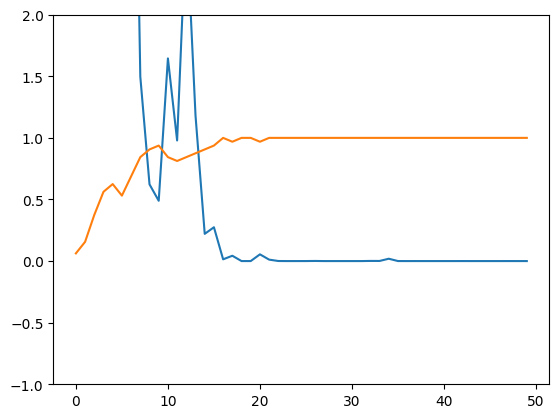

In [56]:
plt.ylim(-1, 2)
plot(losses)
plot(accs)